## Problem 7.3 - Handwritten Digit Recognition

In [8]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

In [9]:
import urllib.request
import gzip
import shutil
import numpy as np
import pandas as pd
urllib.request.urlretrieve("https://hastie.su.domains/ElemStatLearn/datasets/zip.train.gz",filename='./digits_train')
with gzip.open('digits_train', 'rb') as f_in:
    with open('digits_train.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    
# Load into data frame
data_train = pd.read_csv('digits_train.txt', header=None, delimiter= ' ')

# Extract features x and labels y
x = data_train.iloc[:, 1:-1].values # Training data has one column of NaN entries
y = data_train.iloc[:, 0].values

### Approach 1: 3-nearest neighbors

In [15]:
def get_knn_error(X_train, y_train, X_test, y_test, m):

    indices = np.random.choice(len(X_train), size = m, replace = False)
    X_train = X_train[indices]
    y_train = y_train[indices]

    knn = KNeighborsClassifier(n_neighbors = 3)
    knn.fit(X_train, y_train)
    return 1 - knn.score(X_test, y_test)

### Approach 2: m-clustering

In [16]:
def get_clustering_error(X_train, y_train, X_test, y_test, n_clusters):
    kmeans = KMeans(n_clusters, random_state = 42)
    kmeans.fit(X_train)

    cluster_to_label = {}
    for cluster in range(n_clusters):
        data_indices = np.where(kmeans.labels_ == cluster)[0]
        chosen_index = np.random.choice(data_indices)
        cluster_to_label[cluster] = y_train[chosen_index]

    test_clusters = kmeans.predict(X_test)
    y_pred = np.array([cluster_to_label[cluster] for cluster in test_clusters])
    classification_error = np.mean(y_pred != y_test)
    return classification_error

### Approach 3: merge clustering and nearest-neighbors

In [17]:
def get_combined_error(X_train, y_train, X_test, y_test, n_clusters):
    kmeans = KMeans(n_clusters, random_state = 42)
    kmeans.fit(X_train)

    cluster_to_label = {}
    for cluster in range(n_clusters):
        data_indices = np.where(kmeans.labels_ == cluster)[0]
        chosen_index = np.random.choice(data_indices)
        cluster_to_label[cluster] = y_train[chosen_index]

    y_train_cluster_labels = np.array([cluster_to_label[c] for c in kmeans.labels_])

    knn = KNeighborsClassifier(n_neighbors = 3)
    knn.fit(X_train, y_train_cluster_labels)

    return 1 - knn.score(X_test, y_test)

### Test all approaches and plot their error rate

In [18]:
m_values = list(range(3, 211, 3))
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [21]:
errors_knn = []
errors_clustering = []
errors_combined = []
for m in m_values:
    errors_knn.append(get_knn_error(X_train, y_train, X_test, y_test, m))
    errors_clustering.append(get_clustering_error(X_train, y_train, X_test, y_test, m))
    errors_combined.append(get_combined_error(X_train, y_train, X_test, y_test, m))

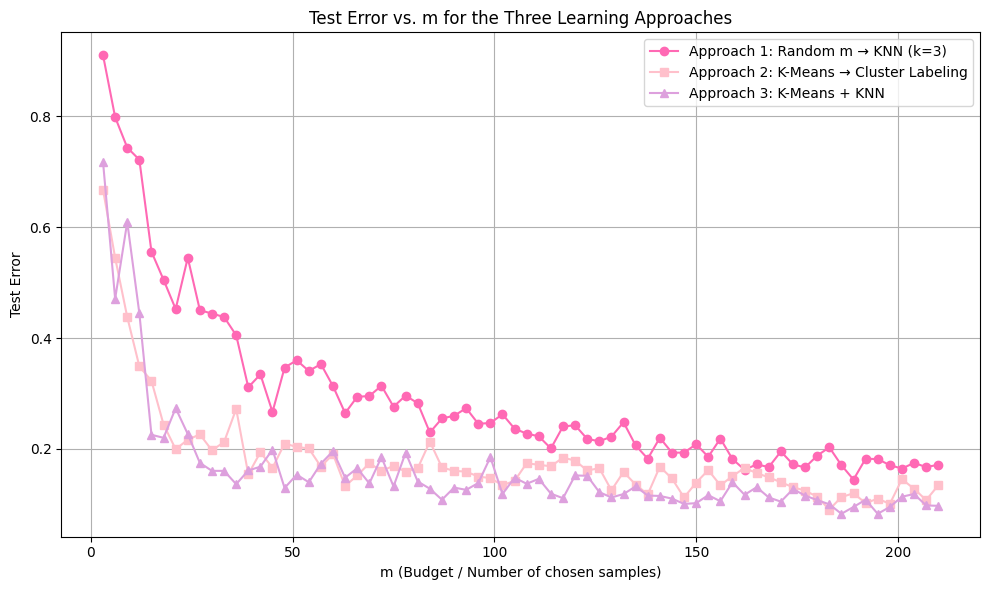

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(m_values, errors_knn, marker = 'o', label = "Approach 1: Random m → KNN (k=3)", color = 'hotpink')
plt.plot(m_values, errors_clustering, marker = 's', label = "Approach 2: K-Means → Cluster Labeling", color = 'pink')
plt.plot(m_values, errors_combined, marker = '^', label = "Approach 3: K-Means + KNN", color = 'plum')

plt.xlabel("m (Budget / Number of chosen samples)")
plt.ylabel("Test Error")
plt.title("Test Error vs. m for the Three Learning Approaches")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Approach 4: cluster and choose cluster label via neighboring majority

In [23]:
l_values = [1,3,5]

In [29]:
def approach_4_error(X_train, y_train, X_test, y_test, m, l):
    n_clusters = max(m // l, 1)
    kmeans = KMeans(n_clusters, random_state = 0)
    kmeans.fit(X_train)

    cluster_to_label = {}
    for cluster in range(n_clusters):
        data_indices = np.where(kmeans.labels_ == cluster)[0]
        cluster_points = X_train[data_indices]

        center = kmeans.cluster_centers_[cluster]
        distances = np.linalg.norm(cluster_points - center, axis = 1)
        nearest_indices = np.argsort(distances)[:l]

        nearest_labels = y_train[data_indices][nearest_indices]
        unique, counts = np.unique(nearest_labels, return_counts=True)
        majority_label = unique[np.argmax(counts)]
        cluster_to_label[cluster] = majority_label
    
    y_train_cluster_labels = np.array([cluster_to_label[c] for c in kmeans.labels_])
    knn = KNeighborsClassifier(n_neighbors = 3)
    knn.fit(X_train, y_train_cluster_labels)

    return 1 - knn.score(X_test, y_test)

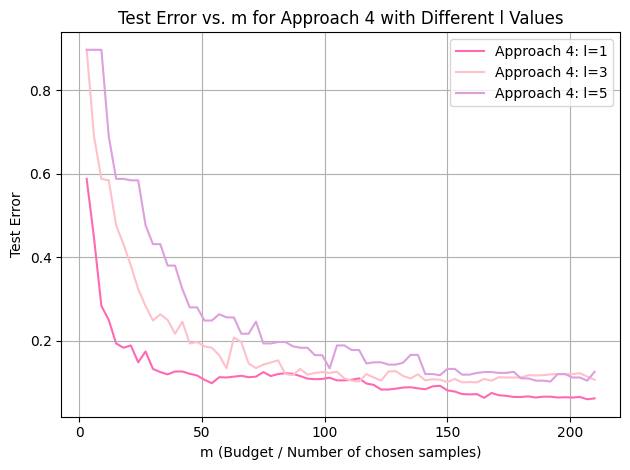

In [30]:
colors = ['hotpink', 'pink', 'plum']

for i, l in enumerate(l_values):
    errors_approach_4 = []
    for m in m_values:
        errors_approach_4.append(approach_4_error(X_train, y_train, X_test, y_test, m, l))
    
    plt.plot(m_values, errors_approach_4, label = f"Approach 4: l={l}", color = colors[i % len(colors)])

plt.xlabel("m (Budget / Number of chosen samples)")
plt.ylabel("Test Error")
plt.title("Test Error vs. m for Approach 4 with Different l Values")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()